In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Evaluating the model

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_squared_error , root_mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('Salary_Data_v2.csv')

In [4]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


Text(0.5, 1.0, 'Salary Prediction')

<Figure size 300x300 with 0 Axes>

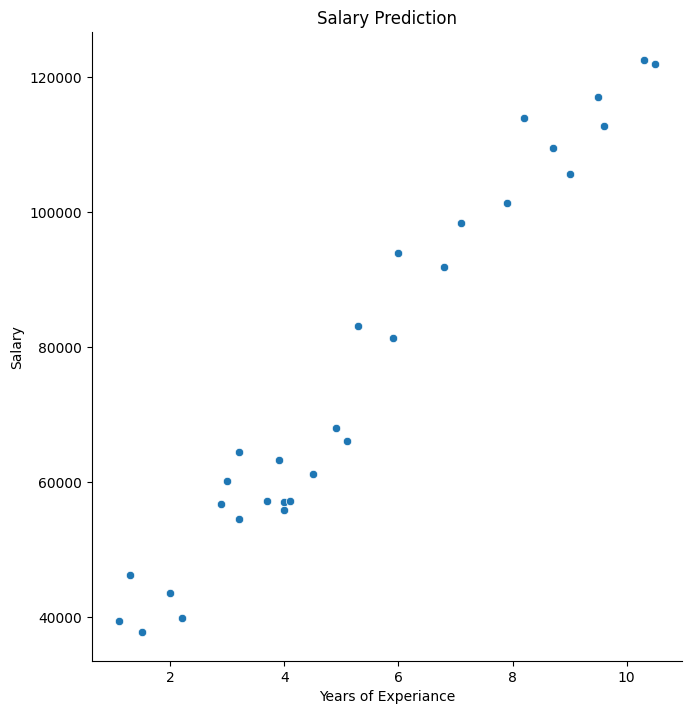

In [5]:
plt.figure(figsize=(3,3))
sns.pairplot(data, x_vars=['YearsExperience'] , y_vars=['Salary'] , size=7 , kind='scatter')
plt.xlabel('Years of Experiance')
plt.ylabel('Salary')
plt.title("Salary Prediction")

In [33]:
x = data.iloc[:,:-1]
y = data.iloc[:,1]

x_train, x_test , y_train ,  y_test = train_test_split(x , y , train_size=0.8 , random_state=11)

print(x_train.shape)

(24, 1)


In [17]:
linear_model = LinearRegression()
linear_model.fit( x_train , y_train )

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


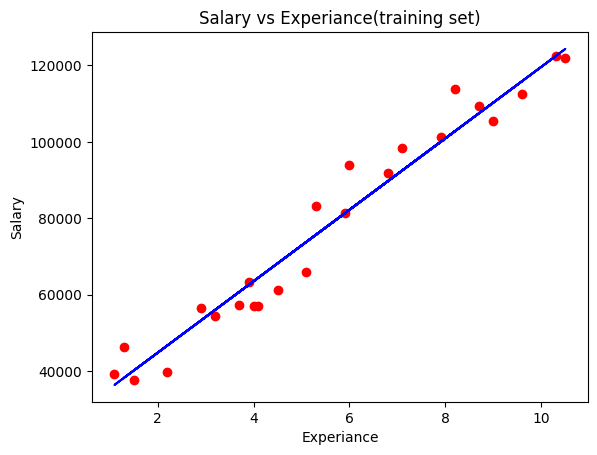

In [34]:
plt.scatter(x_train , y_train , color='red')
plt.plot(x_train , linear_model.predict(x_train) , color = 'blue')
plt.title("Salary vs Experiance(training set)")
plt.xlabel("Experiance")
plt.ylabel("Salary")
plt.show()

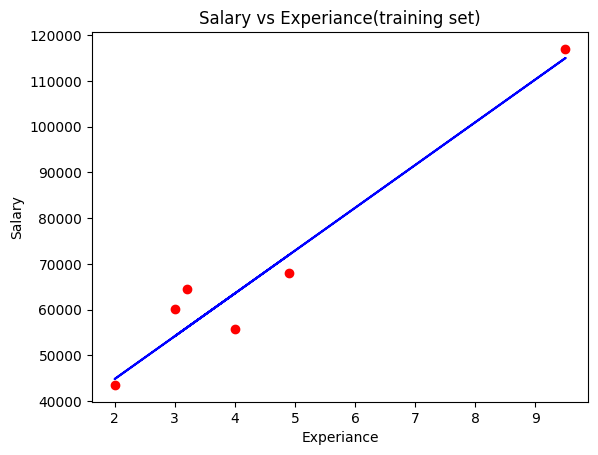

In [35]:
plt.scatter(x_test , y_test , color='red')
plt.plot(x_test , linear_model.predict(x_test) , color = 'blue')
plt.title("Salary vs Experiance(training set)")
plt.xlabel("Experiance")
plt.ylabel("Salary")
plt.show()

In [10]:
x_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [11]:
pd.DataFrame(y_test).T.values

array([[112635.,  67938., 113812.,  83088.,  64445.,  57189.]])

In [12]:
y_pred = linear_model.predict(x_test)
y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

In [13]:
mse = mean_squared_error(y_test , y_pred)
print(mse)

rmse = root_mean_squared_error(y_test , y_pred)
print(rmse)

49830096.85590839
7059.04362190151


In [14]:
r2_sc = r2_score(y_test , y_pred)
print(r2_sc)

0.9024461774180497
